For performing new tracing first import and make Tracer object based on config file settings.
The config file contains locations of images and ROIs for tracing, as well as settings for tracing, quality control and data output and saving.

In [1]:
from tracer import Tracer
import image_processing_functions.tracing_functions as tr
config_path = r"C:\Git\chromatin-team-common-code\chromatin_tracing_python\Config\tracing_config.yaml"
T=Tracer(config_path)

NB! If only loading already traced data, skip to the next step!

Next, run the automated tracing workflow, which outputs traces, images and pairwise distance matrices, based on guassian fits to the brightest point in the manual ROIs. The functions saves these to the output folder as well:

In [ ]:
traces,imgs=T.tracing_multi()
pwds = tr.pwd_calc(traces)

If the analysis has already been run before, we can load the data instead:

In [2]:
import pandas as pd
import numpy as np
import os
wdir = r"M:\ChromatinTeam\Images_processing\20200304_Exp321_ELYRA_BS32-40_lowres_SP6G_2xA565_bruker\05_Trace_Analysis"+os.sep
traces = pd.read_hdf(wdir+"20200304_Exp321_ELYRA_BS32-40_out_traces.h5")
pwds = np.load(wdir+"20200304_Exp321_ELYRA_BS32-40_out_pwds.npy")

Once we have the traces loaded or calculated, we can look at the trace dataframe. It has a multilevel index with a unique trace ID as main index, and image name, nuclear ownership and frame nr as secondary index for each point. Each fitted point is documented with the full output of the gaussian fit, as well as a quality control metric defined from the config file. Units in nm.

In [ ]:
traces.head()

We can easily visualize one or more traces by their trace_IDs now, either one or several (by a list of trace_IDs). To do this we load the tracing functions module that contains several helper functions for trace analysis.

In [ ]:
tr.plot_traces(traces,[5,10])

Depending on the quality of the dataset, some traces might be too short for a useful anaylsis. These can be filtered out from the traces and pair-wise distance matrix before analysing further. Once filtered, we can get a sense of the data from the average pwd matrix (missing distances are nan, so we have to use nanmean).

In [3]:
traces_long, pwds_long = tr.tracing_length_qc(traces, pwds, min_length=8)
excluded = [11, 18, 20, 22, 8]
traces_long_exc=traces_long.drop(excluded, level=0)
pwds_long_exc = tr.pwd_calc(traces_long_exc)

Data saved
Number of traces in analysis:  15


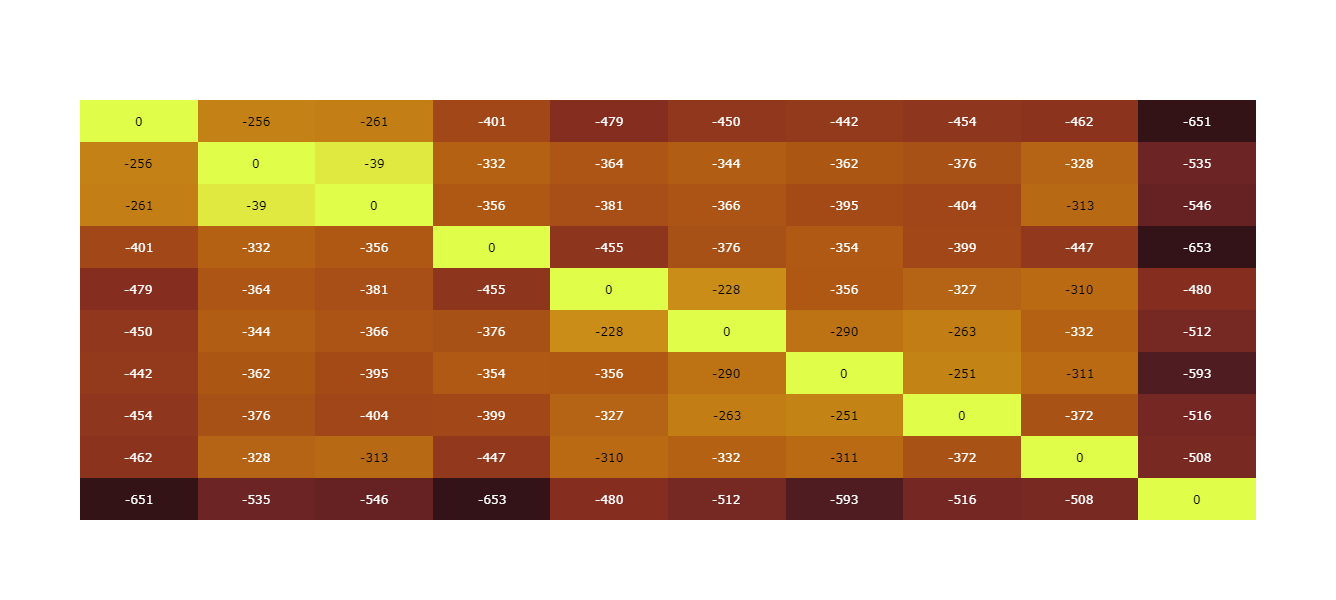

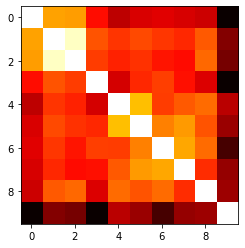

In [17]:
T.save_data(traces=traces_long_exc, pwds=pwds_long_exc, suffix='_min8_exc_')
import matplotlib.pyplot as plt
print('Number of traces in analysis: ', pwds_long_exc.shape[0])
pwds_mean=np.round(-np.nanmean(pwds_long_exc, axis=0),0).astype(int)
plt.imshow(pwds_mean, cmap='hot')

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale= 'solar')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()


Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [8]:
pairs = tr.trace_analysis(traces_long_exc, pwds_long_exc)
T.save_data(pairs=pairs, suffix='_min8_')
pairs.sort_values(by=['pwd_pcc'], ascending=False).head()

Data saved


C:\Users\ellenberg\Anaconda3\lib\site-packages\pandas\core\generic.py:2505: PerformanceWarning:


your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['A', 'A_idx', 'B', 'B_idx', 'B_aligned', 'B_aligned_idx'], dtype='object')]




,idx1,idx2,A,A_idx,B,B_idx,B_aligned,B_aligned_idx,aligned_mse,pwd_mse,pwd_pcc
90,23,24,"[[1240.5537094084193, 1056.0604024101747, 1479...","Int64Index([0, 1, 2, 4, 5, 6, 7, 9], dtype='in...","[[836.2058583078626, 596.8956356789059, 1036.7...","Int64Index([0, 1, 2, 4, 5, 6, 7, 8, 9], dtype=...","[[1285.3814939027968, 939.4062407573414, 1554....","Int64Index([0, 1, 2, 4, 5, 6, 7, 8, 9], dtype=...",4640.148278,15553.680414,0.864213
64,12,24,"[[1362.1428228315326, 1317.2547434467056, 1520...","Int64Index([0, 1, 2, 4, 5, 6, 7, 8, 9], dtype=...","[[836.2058583078626, 596.8956356789059, 1036.7...","Int64Index([0, 1, 2, 4, 5, 6, 7, 8, 9], dtype=...","[[1368.2468626574023, 1358.7745999962629, 1617...","Int64Index([0, 1, 2, 4, 5, 6, 7, 8, 9], dtype=...",19717.887637,30181.450506,0.813720
10,1,25,"[[1371.500643049776, 808.2354057786827, 1336.4...","Int64Index([0, 3, 4, 5, 6, 7, 8, 9], dtype='in...","[[1240.789179516555, 778.1339338599366, 1524.5...","Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 9], dtype=...","[[1504.4018232317949, 766.1775460666648, 1494....","Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 9], dtype=...",29265.582850,18860.789642,0.763648
27,5,7,"[[1675.066264129015, 1762.1238315093576, 1334....","Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=...","[[1647.851509861472, 1800.9119968576977, 1978....","Int64Index([1, 2, 3, 4, 5, 6, 7, 8], dtype='in...","[[1694.3787060932566, 1707.7289846813892, 1501...","Int64Index([1, 2, 3, 4, 5, 6, 7, 8], dtype='in...",17525.751843,46648.901677,0.733241
43,7,19,"[[1647.851509861472, 1800.9119968576977, 1978....","Int64Index([1, 2, 3, 4, 5, 6, 7, 8], dtype='in...","[[1351.3289350914856, 1070.464878461902, 1373....","Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=...","[[1199.9950183148296, 2010.121340728715, 1685....","Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=...",17407.172092,42762.550523,0.731116


We can visualize the aligned traces by their index in the pair matrix.

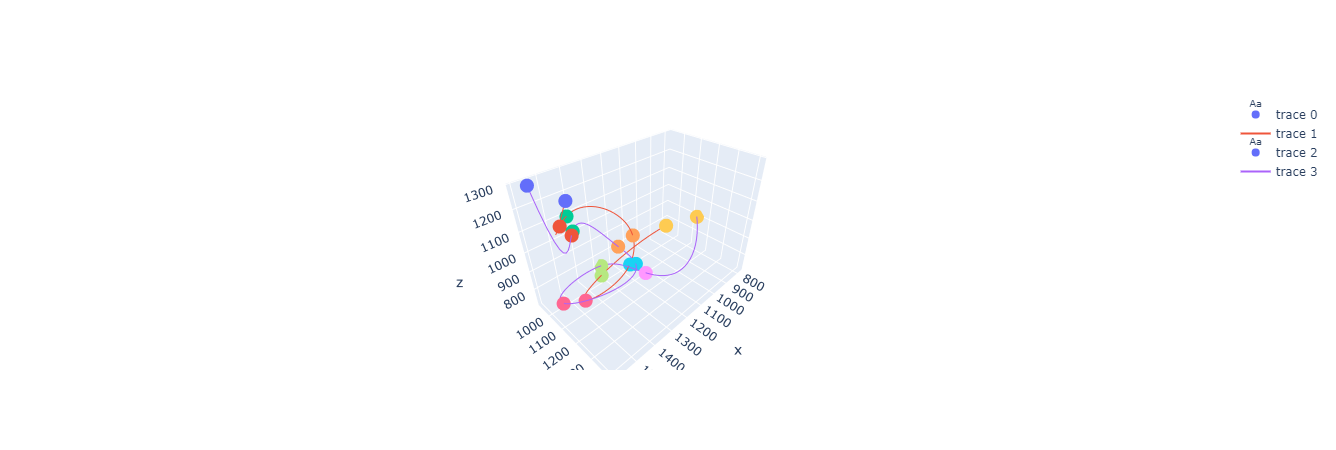

In [9]:
tr.plot_paired_traces(pairs, 90)

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

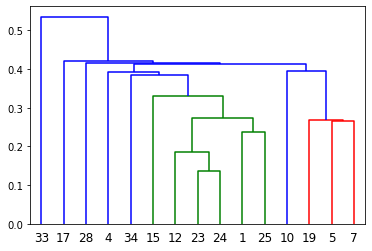

In [10]:
Z = tr.trace_clustering(pairs, metric='pwd_pcc')

We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.

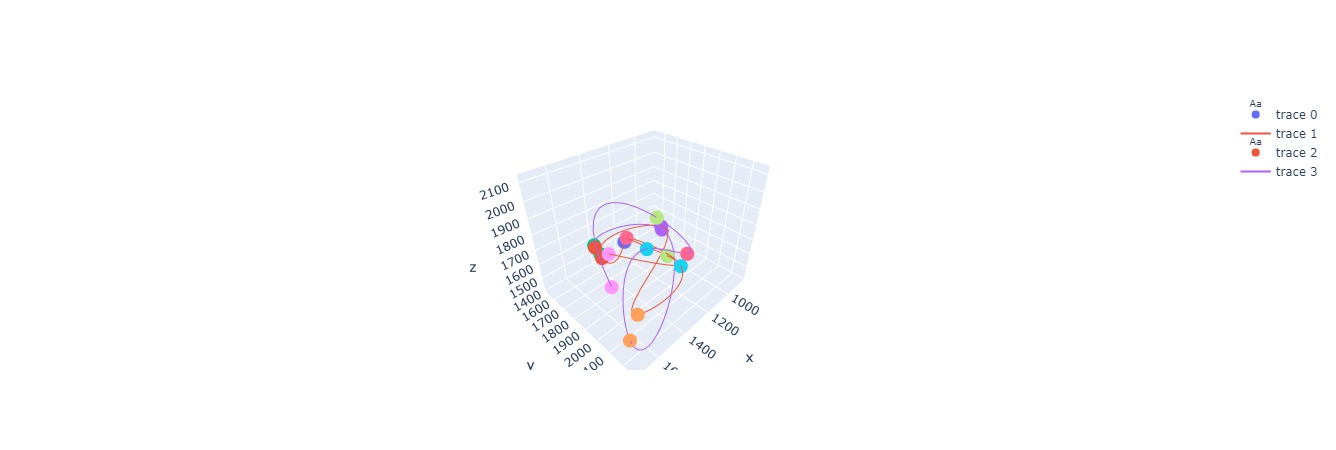

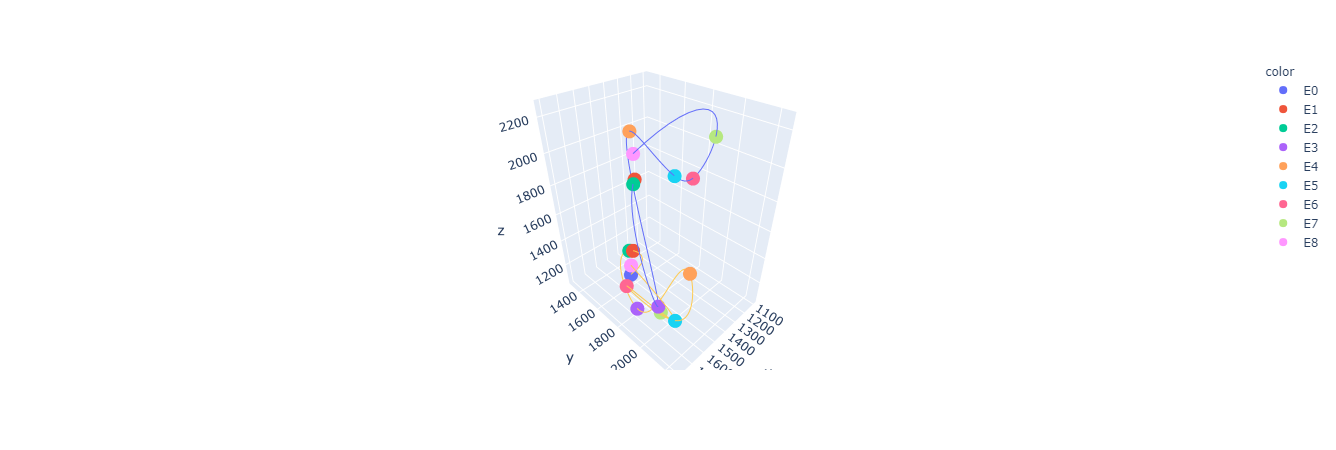

In [11]:
idx=pairs[(pairs['idx1']==5) & (pairs['idx2']==7)].index[0]
tr.plot_paired_traces(pairs, idx)
tr.plot_traces(traces,[5,7])